In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import math

plt.style.use('seaborn-v0_8') # I personally prefer seaborn for the graph style, but you may choose whichever you want.
params = {"ytick.color" : "black",
          "xtick.color" : "black",
          "axes.labelcolor" : "black",
          "axes.edgecolor" : "black",
          "text.usetex" : True,
          "font.family" : "serif",
          "font.serif" : ["Computer Modern Serif"]}
plt.rcParams.update(params)

output_dir = "/Users/russell/projects/stencil_research/fft_bench/plots"
width = 15
height_ratio = 0.41114

In [25]:
warmup_iter = 2

results_dirs = [
    "/Users/russell/projects/stencil_research/fft_bench/results/expanse_1",
    "/Users/russell/projects/stencil_research/fft_bench/results/expanse_2",
]

plan_data_t1 = {
    "Estimate": {},
    "Measure": {},
    "Patient": {},
}

plan_data_t16 = {
    "Estimate": {},
    "Measure": {},
    "Patient": {},
}

def load_results_file(path):
    with open(json_path, 'r') as json_file:
        data = json.load(json_file)
        plan_data = {}
        if data["threads"] == 1:
            plan_data = plan_data_t1
        if data["threads"] == 16:
            plan_data = plan_data_t16
        else:
            return
        plan_type = data["plan_type"]
        time = np.average(data["timings"][warmup_iter:])
        plan_size = data["plan_size"]
        plan_data[plan_type][plan_size] = time
        
for results_dir in results_dirs:  
    for file in sorted(os.listdir(results_dir)):
        json_path = f"{results_dir}/{file}"
        load_results_file(json_path)

In [27]:
plot_data = {}
for plan_type in plan_data_t1.keys():
    name = f"{plan_type} 1 Thread"
    plan_sizes = sorted(plan_data[plan_type].keys())
    times = [plan_data[plan_type][plan_size] for plan_size in plan_sizes]
    plot_data[name] = {}
    plot_data[name]["plan_sizes"] = plan_sizes
    plot_data[name]["times"] = times

for plan_type in plan_data_t16.keys():
    name = f"{plan_type} 16 Threads"
    plan_sizes = sorted(plan_data[plan_type].keys())
    times = [plan_data[plan_type][plan_size] for plan_size in plan_sizes]
    plot_data[name] = {}
    plot_data[name]["plan_sizes"] = plan_sizes
    plot_data[name]["times"] = times

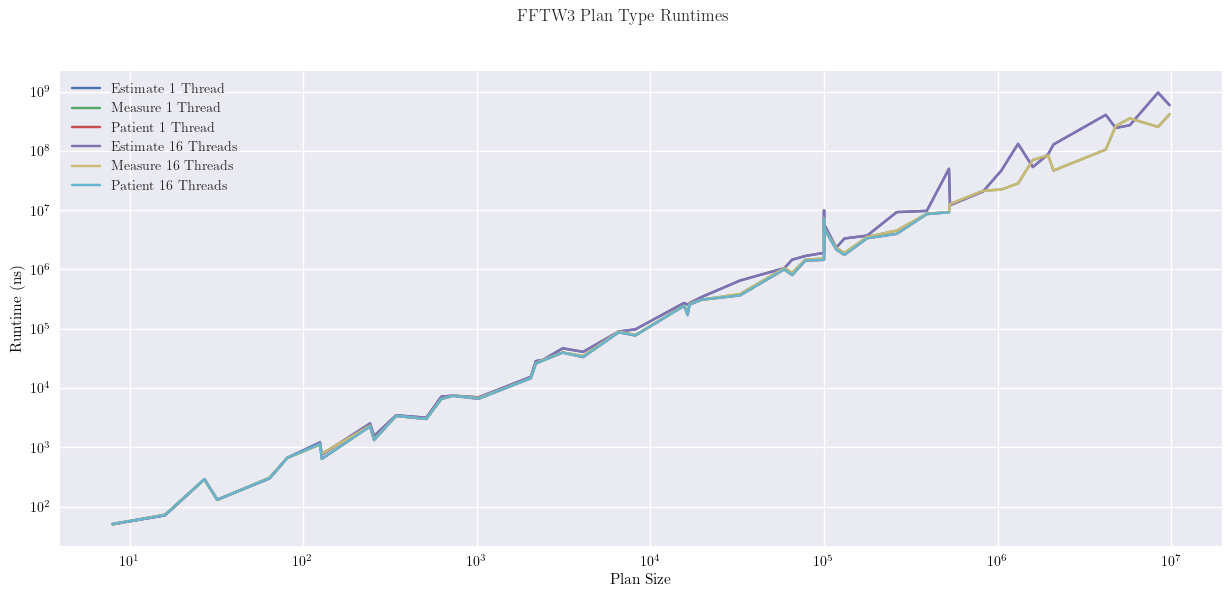

In [28]:
fig = plt.figure(figsize=(width, width * height_ratio))
n_rows = 1
n_cols = 1
width_ratios = [1.0]
height_ratios = [1.0]
gs1 = fig.add_gridspec(
    n_rows, n_cols,
    width_ratios = width_ratios, 
    height_ratios = height_ratios,
    wspace = 0.15,
    hspace = 0.15,
)
ax = fig.add_subplot(gs1[0, 0])

for plan_type in plot_data.keys():
    ax.plot(plot_data[plan_type]["plan_sizes"], plot_data[plan_type]["times"], label=plan_type)
    
ax.legend()
ax.set_ylabel("Runtime (ns)")
ax.set_xlabel("Plan Size")
ax.set_xscale('log')
ax.set_yscale('log')
fig.suptitle("FFTW3 Plan Type Runtimes")
plt.savefig(f"{output_dir}/plan_type_runtimes.pdf")